# GMU-GNN Static–Dynamic Crime Forecasting

This notebook preserves the original data loading, feature extraction, smoothing,
normalization, temporal split, node split utilities, and PyG datasets. Only the
model and post-model analyses are replaced.

The model uses the established **Gated Multimodal Unit (GMU)** to fuse static
socioeconomic features and a dynamic crime window at every node. The resulting
joint node representation is passed to a standard graph neural network.


## Architecture

For node $i$ at window $t$:

$$
\mathbf{h}^{s}_{i}=\tanh(W_s\mathbf{x}^{s}_{i}+b_s),\qquad
\mathbf{h}^{d}_{i,t}=\tanh(W_d\mathbf{x}^{d}_{i,t}+b_d),
$$

$$
\mathbf{z}_{i,t}=\sigma\left(W_z[\mathbf{x}^{s}_{i}\Vert
\mathbf{x}^{d}_{i,t}]+b_z\right),
$$

$$
\mathbf{h}^{GMU}_{i,t}=\mathbf{z}_{i,t}\odot\mathbf{h}^{s}_{i}
+(1-\mathbf{z}_{i,t})\odot\mathbf{h}^{d}_{i,t}.
$$

$\mathbf{z}_{i,t}$ is a feature-wise gate: values near 1 favor the static
representation and values near 0 favor the dynamic representation. Graph
message passing occurs after GMU fusion, making this an intermediate
feature-fusion GNN baseline rather than fusion inside message construction.


## What remains unchanged

- Static and dynamic feature selection
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window dataset construction
- Existing temporal and node-split setup

The replacement section contains the GMU-GNN, leakage-free fixed-epoch training,
evaluation, gate analysis, modality ablation, neighborhood time-series plots,
gradient sensitivity, and embedding visualization.


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 50

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'GMU_GraphConv'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "GMU_GNN_inductive_learning"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# GMU fusion and graph model

The GMU is applied independently at every node and time window. Its fused
representation is then propagated over the existing street graph with
`GraphConv`. This is the clean GMU-GNN baseline to compare with fusion inside
your custom message function.


In [24]:
import copy
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv


class GatedMultimodalUnit(nn.Module):
    """Feature-wise GMU for static and dynamic node modalities."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim):
        super().__init__()
        self.static_encoder = nn.Linear(static_dim, hidden_dim)
        self.dynamic_encoder = nn.Linear(dynamic_dim, hidden_dim)
        self.gate_layer = nn.Linear(static_dim + dynamic_dim, hidden_dim)
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (self.static_encoder, self.dynamic_encoder, self.gate_layer):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x_static, x_dynamic):
        h_static = torch.tanh(self.static_encoder(x_static))
        h_dynamic = torch.tanh(self.dynamic_encoder(x_dynamic))
        gate_static = torch.sigmoid(
            self.gate_layer(torch.cat([x_static, x_dynamic], dim=-1))
        )
        h_fused = gate_static * h_static + (1.0 - gate_static) * h_dynamic
        return h_fused, gate_static, h_static, h_dynamic


class GMUGraphForecastModel(nn.Module):
    def __init__(self, static_dim, dynamic_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.gmu = GatedMultimodalUnit(static_dim, dynamic_dim, hidden_dim)
        self.conv1 = GraphConv(hidden_dim, hidden_dim)
        self.conv2 = GraphConv(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = dropout
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_static, x_dynamic, edge_index, return_details=False):
        h_gmu, gate, h_static, h_dynamic = self.gmu(x_static, x_dynamic)

        h = self.conv1(h_gmu, edge_index)
        h = self.norm1(F.relu(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        h = self.norm2(F.relu(h))

        prediction = self.regressor(h).squeeze(-1)
        if return_details:
            return prediction, h, {
                "gate": gate,
                "h_static": h_static,
                "h_dynamic": h_dynamic,
                "h_gmu": h_gmu,
            }
        return prediction, h


# Model initialization


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = GMUGraphForecastModel(
    static_dim=S,
    dynamic_dim=W,
    hidden_dim=64,
    dropout=0.6,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


GMUGraphForecastModel(
  (gmu): GatedMultimodalUnit(
    (static_encoder): Linear(in_features=11, out_features=64, bias=True)
    (dynamic_encoder): Linear(in_features=5, out_features=64, bias=True)
    (gate_layer): Linear(in_features=16, out_features=64, bias=True)
  )
  (conv1): GraphConv(64, 64)
  (conv2): GraphConv(64, 64)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Device: cpu
Trainable parameters: 27457


# Training

Because the supplied preprocessing creates only training and test datasets,
the model is trained for the configured fixed number of epochs. The test set is
not used for early stopping or checkpoint selection.


In [26]:
def _move_batch(data, device):
    return data.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(data, device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        static_gate_sum += details["gate"].detach().sum().item()
        gate_elements += details["gate"].numel()

    return total_loss / max(total_nodes, 1), static_gate_sum / max(gate_elements, 1)


train_loss_history = []
static_gate_history = []

for epoch in range(num_epochs):
    train_loss, static_gate_mean = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    train_loss_history.append(train_loss)
    static_gate_history.append(static_gate_mean)

    if epoch == 0 or (epoch + 1) % 10 == 0 or epoch + 1 == num_epochs:
        print(
            f"Epoch {epoch + 1:03d}/{num_epochs} | "
            f"Train MSE: {train_loss:.6f} | "
            f"GMU static gate: {static_gate_mean:.4f} | "
            f"dynamic gate: {1.0-static_gate_mean:.4f}"
        )


Epoch 001/50 | Train MSE: 0.024960 | GMU static gate: 0.5006 | dynamic gate: 0.4994
Epoch 010/50 | Train MSE: 0.001499 | GMU static gate: 0.4922 | dynamic gate: 0.5078
Epoch 020/50 | Train MSE: 0.000777 | GMU static gate: 0.4826 | dynamic gate: 0.5174
Epoch 030/50 | Train MSE: 0.000559 | GMU static gate: 0.4774 | dynamic gate: 0.5226
Epoch 040/50 | Train MSE: 0.000450 | GMU static gate: 0.4739 | dynamic gate: 0.5261
Epoch 050/50 | Train MSE: 0.000387 | GMU static gate: 0.4711 | dynamic gate: 0.5289


# Training and gate-history plots


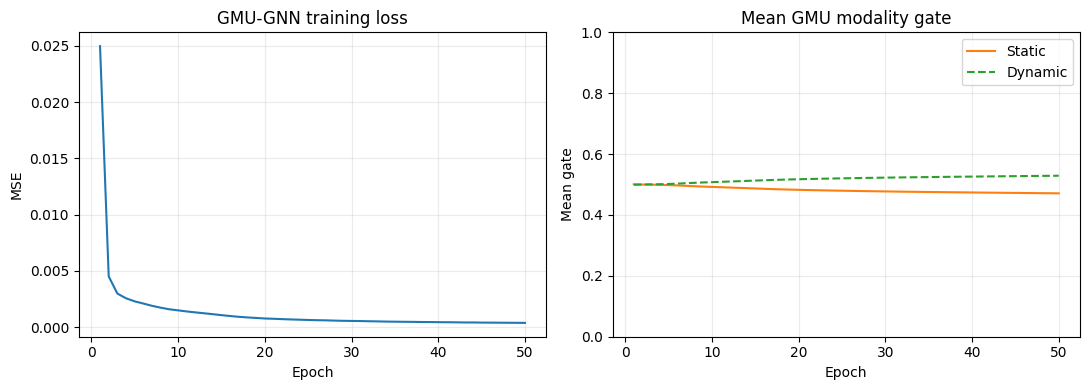

In [27]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="GMU-GNN training loss", xlabel="Epoch", ylabel="MSE")
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, static_gate_history, label="Static", color="tab:orange")
axes[1].plot(
    epochs, 1.0 - np.asarray(static_gate_history),
    label="Dynamic", color="tab:green", linestyle="--"
)
axes[1].set(title="Mean GMU modality gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_training_and_gate_history.png"), dpi=300, bbox_inches="tight")
plt.show()


# Test evaluation and collection


In [28]:
@torch.no_grad()
def evaluate_and_collect_gmu(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time = []
    targets_per_time = []
    embeddings_per_time = []
    gates_per_time = []
    node_ids_per_time = []
    time_ids_per_time = []

    for step, data in enumerate(loader):
        data = _move_batch(data, device)
        x_static = data.x_static
        x_dynamic = data.x_dynamic

        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)

        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.detach().cpu().numpy())
        targets_per_time.append(target.detach().cpu().numpy())
        embeddings_per_time.append(embedding.detach().cpu())
        gates_per_time.append(details["gate"].detach().cpu())
        node_ids_per_time.append(node_ids.detach().cpu())
        time_ids_per_time.append(time_ids.detach().cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    variance = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(error ** 2) / variance) if variance > 0 else float("nan")

    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": mae,
        "R2": r2,
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "gates_per_time": gates_per_time,
        "gates": torch.cat(gates_per_time, dim=0),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_gmu(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]

display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_GMU_GNN.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000151,0.01227,0.007674,0.948111


# GMU modality contribution

The GMU has a feature-wise gate. For summaries, the gate is averaged over the
hidden dimensions. These values describe the model's learned mixing mechanism;
they are not causal importance scores.


Global mean static gate : 0.4702
Global mean dynamic gate: 0.5298


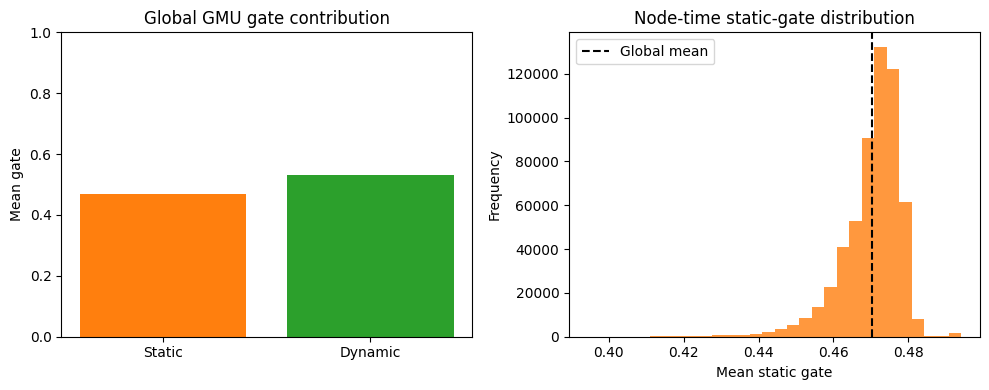

In [29]:
gates = test_results["gates"]                         # [all node-time cases, hidden_dim]
case_static_gate = gates.mean(dim=1)                 # scalar summary per node-time case
global_static_gate = case_static_gate.mean().item()
global_dynamic_gate = 1.0 - global_static_gate

print(f"Global mean static gate : {global_static_gate:.4f}")
print(f"Global mean dynamic gate: {global_dynamic_gate:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Static", "Dynamic"], [global_static_gate, global_dynamic_gate],
            color=["tab:orange", "tab:green"])
axes[0].set(title="Global GMU gate contribution", ylabel="Mean gate", ylim=(0, 1))

axes[1].hist(case_static_gate.numpy(), bins=30, color="tab:orange", alpha=0.8)
axes[1].axvline(global_static_gate, color="black", linestyle="--", label="Global mean")
axes[1].set(title="Node-time static-gate distribution", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_global_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


# Spatial and temporal gate analysis


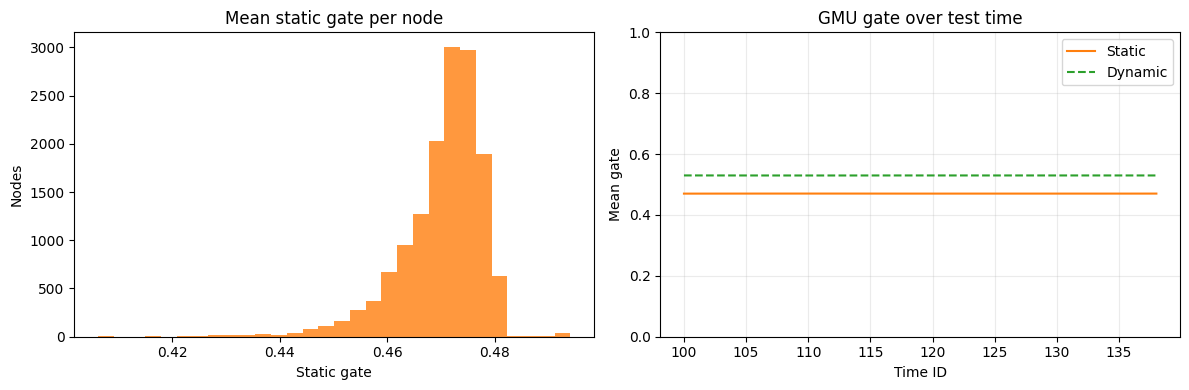

In [30]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "static_gate": case_static_gate.numpy(),
})
gate_frame["dynamic_gate"] = 1.0 - gate_frame["static_gate"]

node_gate = gate_frame.groupby("node_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["static_gate"], bins=30, color="tab:orange", alpha=0.8)
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")

axes[1].plot(time_gate["time_id"], time_gate["static_gate"], label="Static", color="tab:orange")
axes[1].plot(time_gate["time_id"], time_gate["dynamic_gate"], label="Dynamic", color="tab:green", linestyle="--")
axes[1].set(title="GMU gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "gmu_gate_node_time_values.csv"), index=False)


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 451, 'Balanced': 12949, 'Static-heavy': 12949}


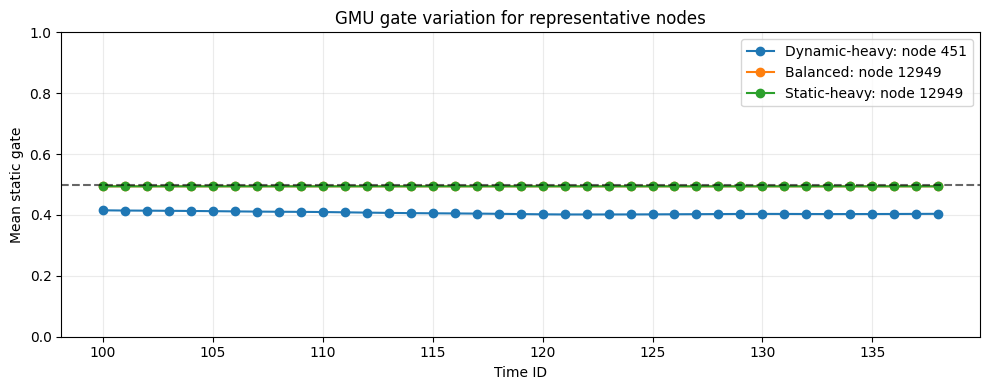

In [31]:
node_gate_sorted = node_gate.sort_values("static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_node = int(node_gate_sorted.iloc[(node_gate_sorted["static_gate"] - 0.5).abs().argmin()]["node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])

selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

plt.figure(figsize=(10, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    plt.plot(series["time_id"], series["static_gate"], marker="o", label=f"{label}: node {node}")
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Time ID")
plt.ylabel("Mean static gate")
plt.title("GMU gate variation for representative nodes")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


# Modality ablation

`Static only` zeros the dynamic input, while `Dynamic only` zeros the static
input. The already-trained full model is not retrained; this measures input
ablation sensitivity. For a stronger paper experiment, also train separate
static-only and dynamic-only GNNs from scratch.


,Input,MSE,RMSE,MAE,R2
0,Full GMU,0.000151,0.012270,0.007674,0.948111
1,Static only,0.003613,0.060112,0.027922,-0.245469
2,Dynamic only,0.000594,0.024364,0.014595,0.795405


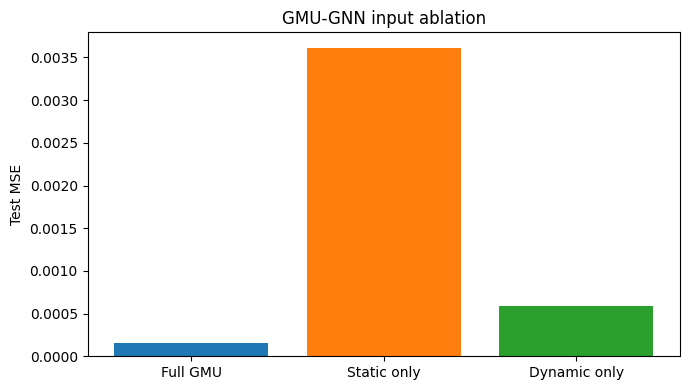

In [32]:
static_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="dynamic_only")

ablation_results = pd.DataFrame([
    {"Input": "Full GMU", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "gmu_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("GMU-GNN input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


# Gradient sensitivity check


In [33]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,5.188552e-07,0.00001


# Predicted time-series and neighborhood analysis


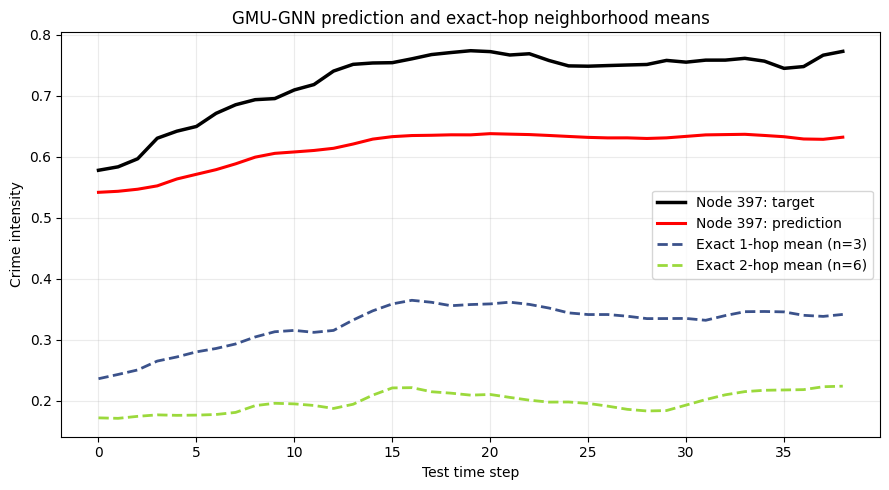

In [34]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="GMU-GNN prediction and exact-hop neighborhood means")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "gmu_high_crime_node_neighborhood.png")
)


# Prediction scatter and residual analysis


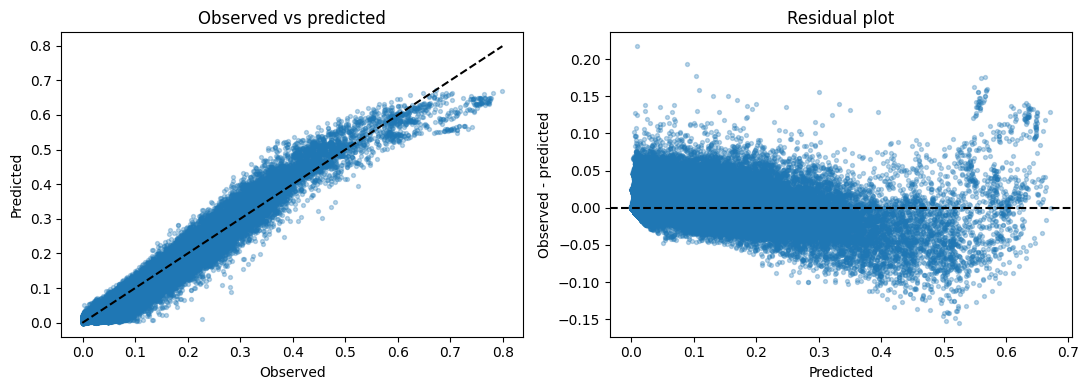

In [35]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


In [36]:
import numpy as np
import pandas as pd
import torch


def _expand_metadata(value, number_of_nodes, device):
    """
    Convert scalar node/time metadata into one value per node.
    """
    if value is None:
        return None

    value = value.reshape(-1)

    if value.numel() == 1 and number_of_nodes > 1:
        value = value.repeat(number_of_nodes)

    return value


@torch.no_grad()
def collect_gate_explainability(
    model,
    loader,
    device,
    model_type,
):
    """
    Collect gate values and crime information.

    Parameters
    ----------
    model:
        Complete trained model.

    loader:
        PyG test or training loader.

    device:
        'cpu', 'cuda', or torch.device.

    model_type:
        One of:
        - 'gmu'
        - 'gmu_gnn'
        - 'm11_vector'

    Returns
    -------
    Dictionary containing node/time IDs, crime intensity,
    target crime, predictions, and gate summaries.
    """

    valid_types = {
        "gmu",
        "gmu_gnn",
        "m11_vector",
    }

    if model_type not in valid_types:
        raise ValueError(
            f"model_type must be one of {valid_types}"
        )

    model.eval()
    device = torch.device(device)

    all_node_ids = []
    all_time_ids = []
    all_input_crime = []
    all_target_crime = []
    all_predictions = []

    # GMU gate
    all_gate_static = []
    all_gate_vectors = []

    # M11 gates
    all_gate_self = []
    all_gate_neigh = []
    all_gate_self_vectors = []
    all_gate_neigh_vectors = []

    for step, data in enumerate(loader):
        data = data.to(device)

        output = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
            return_details=True,
        )

        prediction, embedding, details = output
        prediction = prediction.reshape(-1)

        number_of_nodes = prediction.numel()

        # -----------------------------
        # Node IDs
        # -----------------------------
        node_ids = getattr(
            data,
            "node_ids",
            torch.arange(
                number_of_nodes,
                device=device,
            ),
        )

        node_ids = _expand_metadata(
            node_ids,
            number_of_nodes,
            device,
        )

        # -----------------------------
        # Time IDs
        # -----------------------------
        time_ids = getattr(
            data,
            "time_id",
            torch.tensor(
                step,
                device=device,
            ),
        )

        time_ids = _expand_metadata(
            time_ids,
            number_of_nodes,
            device,
        )

        # Average observed crime in the input window
        input_crime = data.x_dynamic.mean(dim=1)

        # Next-period target
        target_crime = data.y.float().reshape(-1)

        all_node_ids.append(
            node_ids.detach().cpu()
        )
        all_time_ids.append(
            time_ids.detach().cpu()
        )
        all_input_crime.append(
            input_crime.detach().cpu()
        )
        all_target_crime.append(
            target_crime.detach().cpu()
        )
        all_predictions.append(
            prediction.detach().cpu()
        )

        # =============================
        # GMU and GMU-GNN
        # =============================
        if model_type in {"gmu", "gmu_gnn"}:
            gate_vector = details["gate"]

            if gate_vector.ndim == 1:
                gate_vector = gate_vector.unsqueeze(-1)

            # Average across hidden dimensions
            gate_static = gate_vector.mean(dim=-1)

            all_gate_static.append(
                gate_static.detach().cpu()
            )
            all_gate_vectors.append(
                gate_vector.detach().cpu()
            )

        # =============================
        # M11 adaptive vector gates
        # =============================
        elif model_type == "m11_vector":
            gate_self_vector = details["self_gate"]
            gate_neigh_vector = details["neighbor_gate"]

            if gate_self_vector.ndim == 1:
                gate_self_vector = (
                    gate_self_vector.unsqueeze(-1)
                )

            if gate_neigh_vector.ndim == 1:
                gate_neigh_vector = (
                    gate_neigh_vector.unsqueeze(-1)
                )

            gate_self = gate_self_vector.mean(dim=-1)
            gate_neigh = gate_neigh_vector.mean(dim=-1)

            all_gate_self.append(
                gate_self.detach().cpu()
            )
            all_gate_neigh.append(
                gate_neigh.detach().cpu()
            )
            all_gate_self_vectors.append(
                gate_self_vector.detach().cpu()
            )
            all_gate_neigh_vectors.append(
                gate_neigh_vector.detach().cpu()
            )

    results = {
        "node_ids": torch.cat(all_node_ids),
        "time_ids": torch.cat(all_time_ids),
        "input_crime": torch.cat(all_input_crime),
        "target_crime": torch.cat(all_target_crime),
        "predictions": torch.cat(all_predictions),
        "model_type": model_type,
    }

    if model_type in {"gmu", "gmu_gnn"}:
        results.update({
            "gate_static": torch.cat(
                all_gate_static
            ),
            "gate_dynamic": (
                1.0 - torch.cat(all_gate_static)
            ),
            "gate_vectors": torch.cat(
                all_gate_vectors
            ),
        })

    elif model_type == "m11_vector":
        gate_self = torch.cat(all_gate_self)
        gate_neigh = torch.cat(all_gate_neigh)

        results.update({
            "gate_self": gate_self,
            "gate_neigh": gate_neigh,
            "gate_self_dynamic": 1.0 - gate_self,
            "gate_neigh_dynamic": 1.0 - gate_neigh,
            "gate_self_vectors": torch.cat(
                all_gate_self_vectors
            ),
            "gate_neigh_vectors": torch.cat(
                all_gate_neigh_vectors
            ),
        })

    return results

In [37]:
results = collect_gate_explainability(
    model=model,
    loader=test_loader,
    device=device,
    model_type="gmu_gnn",
)

# Interpretation notes

- A GMU gate near 1 favors the static latent representation; a gate near 0
  favors the dynamic latent representation.
- The gate is feature-wise, so its mean is only a compact summary.
- Gate values are learned mixing coefficients, not causal modality effects.
- The ablation experiment complements the gate analysis but does not replace
  separately trained static-only and dynamic-only baselines.
- For fair comparison with your message-level fusion model, use the same graph
  convolution, hidden dimension, optimizer, epochs, and evaluation split.
